# E2E Usecase Metrics

Notebook nay chi ve 3 bieu do:

1. Latency cua tung use case
2. Diem cua tung use case
3. So step dung tren tong so step cua tung use case

In [7]:
# Uncomment neu moi truong chua co thu vien can thiet.
# !pip install pandas matplotlib

In [8]:
from __future__ import annotations

import json
import textwrap
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd


def find_artifact_dir() -> Path:
    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        for candidate in (
            base / "artifacts" / "usecases",
            base / "testing-e2e" / "artifacts" / "usecases",
        ):
            if candidate.is_dir():
                return candidate
    raise FileNotFoundError("Cannot find testing-e2e/artifacts/usecases")


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.titlesize": 15,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "font.family": "DejaVu Sans",
    }
)


def chart_width(row_count: int) -> float:
    return max(12, min(22, row_count * 0.72 + 4))


def wrap_labels(values, width: int = 28):
    return ["\n".join(textwrap.wrap(str(value), width=width, break_long_words=False)) for value in values]


ARTIFACT_DIR = find_artifact_dir()
SUMMARY_PATH = ARTIFACT_DIR / "agent-evaluation-report.json"
ARTIFACT_DIR

WindowsPath('C:/Users/khai/k/V-Claw/testing-e2e/artifacts/usecases')

In [9]:
def load_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def parse_datetime(value):
    if not value:
        return None
    if isinstance(value, (int, float)):
        return datetime.fromtimestamp(value, tz=timezone.utc)
    text = str(value).strip()
    if not text:
        return None
    if text.endswith("Z"):
        text = text[:-1] + "+00:00"
    return datetime.fromisoformat(text)


def latency_seconds(run_report: dict) -> float | None:
    duration_ms = run_report.get("durationMs")
    if isinstance(duration_ms, (int, float)):
        return round(duration_ms / 1000, 3)

    started_at = parse_datetime(run_report.get("startedAt"))
    finished_at = parse_datetime(run_report.get("finishedAt"))
    if started_at and finished_at:
        return round((finished_at - started_at).total_seconds(), 3)
    return None


summary = load_json(SUMMARY_PATH) if SUMMARY_PATH.exists() else {}
eval_by_usecase = {
    item["usecase"]: item
    for item in summary.get("usecases", [])
    if isinstance(item, dict) and item.get("usecase")
}

rows = []
for path in sorted(ARTIFACT_DIR.glob("*.json")):
    if path.name == "agent-evaluation-report.json":
        continue

    run_report = load_json(path)
    if not isinstance(run_report, dict) or "conversation" not in run_report:
        continue

    usecase = str(run_report.get("usecase") or path.stem)
    conversation = run_report.get("conversation") or []
    eval_report = eval_by_usecase.get(usecase, {})
    eval_steps = eval_report.get("steps") or []

    if eval_steps:
        total_steps = len(eval_steps)
        correct_steps = sum(
            1
            for step in eval_steps
            if isinstance(step, dict)
            and isinstance(step.get("llmEvaluation"), dict)
            and step["llmEvaluation"].get("passed") is True
        )
    else:
        total_steps = len(conversation)
        correct_steps = sum(1 for step in conversation if isinstance(step, dict) and step.get("passed") is True)

    score = eval_report.get("score")
    if score is None:
        score = correct_steps / total_steps if total_steps else None

    rows.append(
        {
            "usecase": usecase,
            "latency_s": latency_seconds(run_report),
            "score": score,
            "correct_steps": correct_steps,
            "total_steps": total_steps,
            "wrong_steps": max(total_steps - correct_steps, 0),
            "step_rate": correct_steps / total_steps if total_steps else None,
            "step_label": f"{correct_steps}/{total_steps}",
        }
    )

metrics = pd.DataFrame(rows).sort_values("usecase").reset_index(drop=True)
if metrics.empty:
    raise ValueError(f"No usecase run artifacts found in {ARTIFACT_DIR}")

## Latency by use case

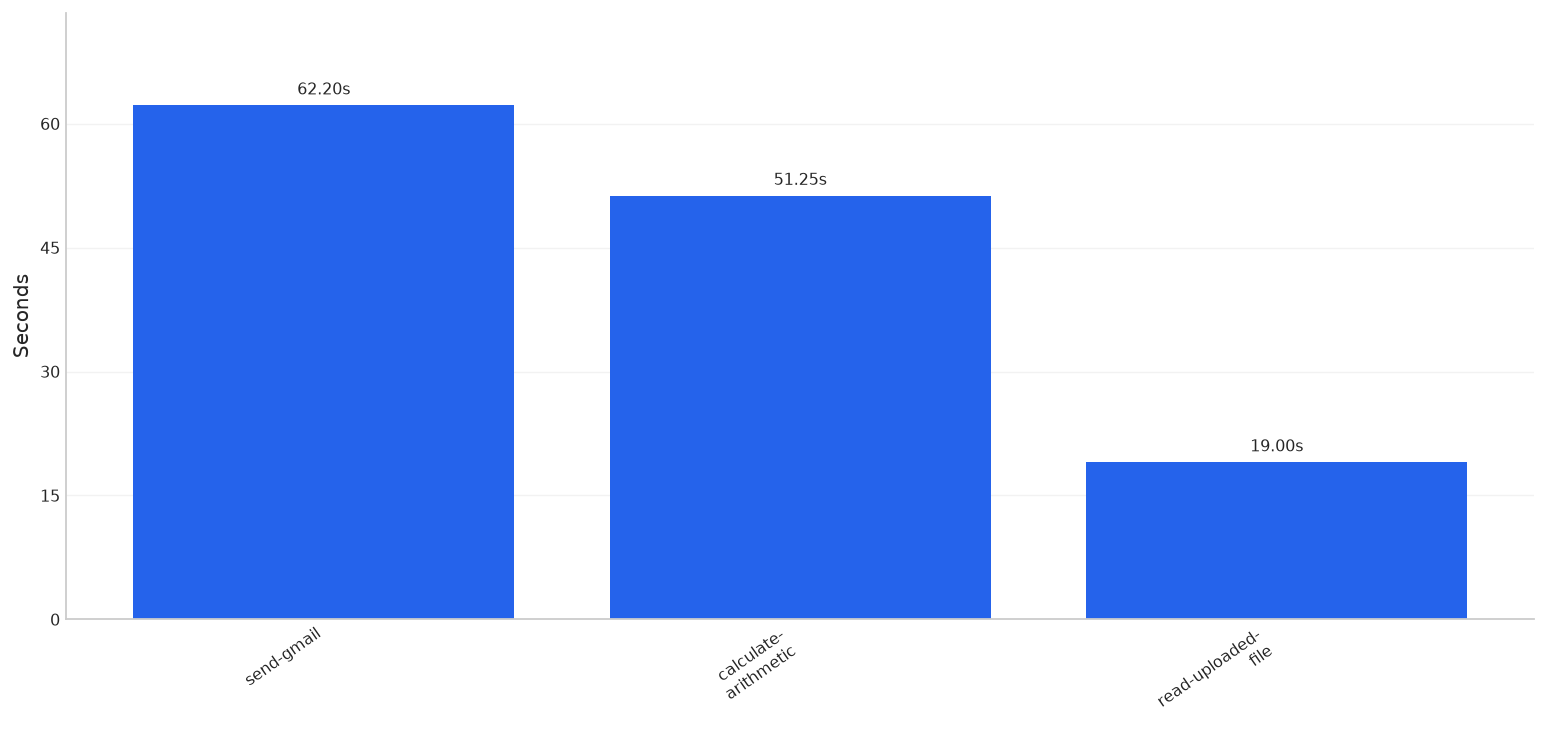

In [10]:
plot_df = metrics.sort_values("latency_s", ascending=False)
labels = wrap_labels(plot_df["usecase"], width=16)

fig, ax = plt.subplots(figsize=(chart_width(len(plot_df)), 5.8))
bars = ax.bar(labels, plot_df["latency_s"], color="#2563eb")

ax.set_xlabel("")
ax.set_ylabel("Seconds")
ax.bar_label(bars, labels=[f"{value:.2f}s" for value in plot_df["latency_s"]], padding=4, fontsize=9)
ax.set_ylim(0, max(plot_df["latency_s"].max() * 1.18, 1))
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
ax.tick_params(axis="x", rotation=35)
for tick in ax.get_xticklabels():
    tick.set_ha("right")
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## Score by use case

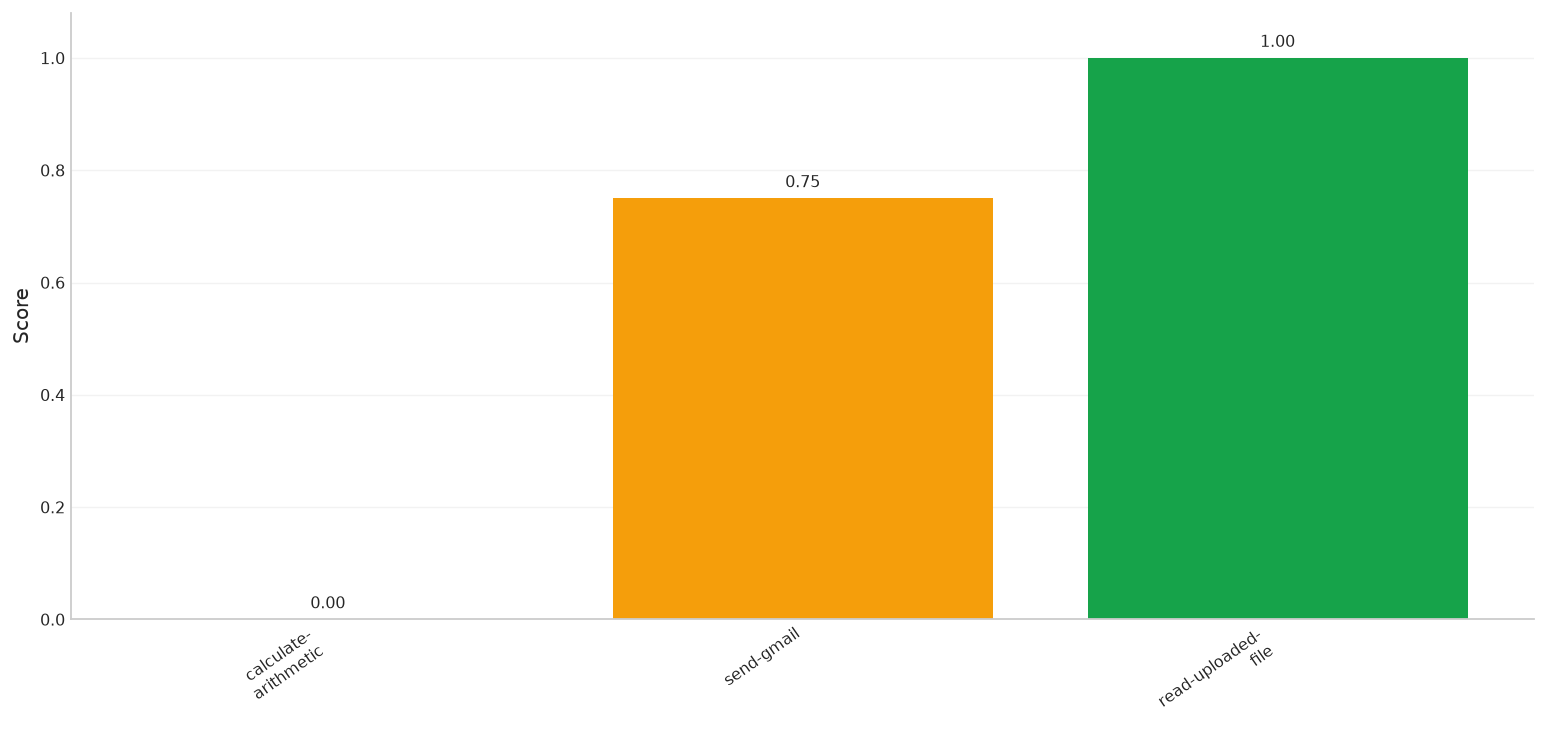

In [11]:
plot_df = metrics.sort_values("score", ascending=True)
labels = wrap_labels(plot_df["usecase"], width=16)
colors = ["#dc2626" if value < 0.5 else "#f59e0b" if value < 0.8 else "#16a34a" for value in plot_df["score"]]

fig, ax = plt.subplots(figsize=(chart_width(len(plot_df)), 5.8))
bars = ax.bar(labels, plot_df["score"], color=colors)

ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.08)
ax.bar_label(bars, labels=[f"{value:.2f}" for value in plot_df["score"]], padding=4, fontsize=9)
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
ax.tick_params(axis="x", rotation=35)
for tick in ax.get_xticklabels():
    tick.set_ha("right")
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## Correct steps / total steps by use case

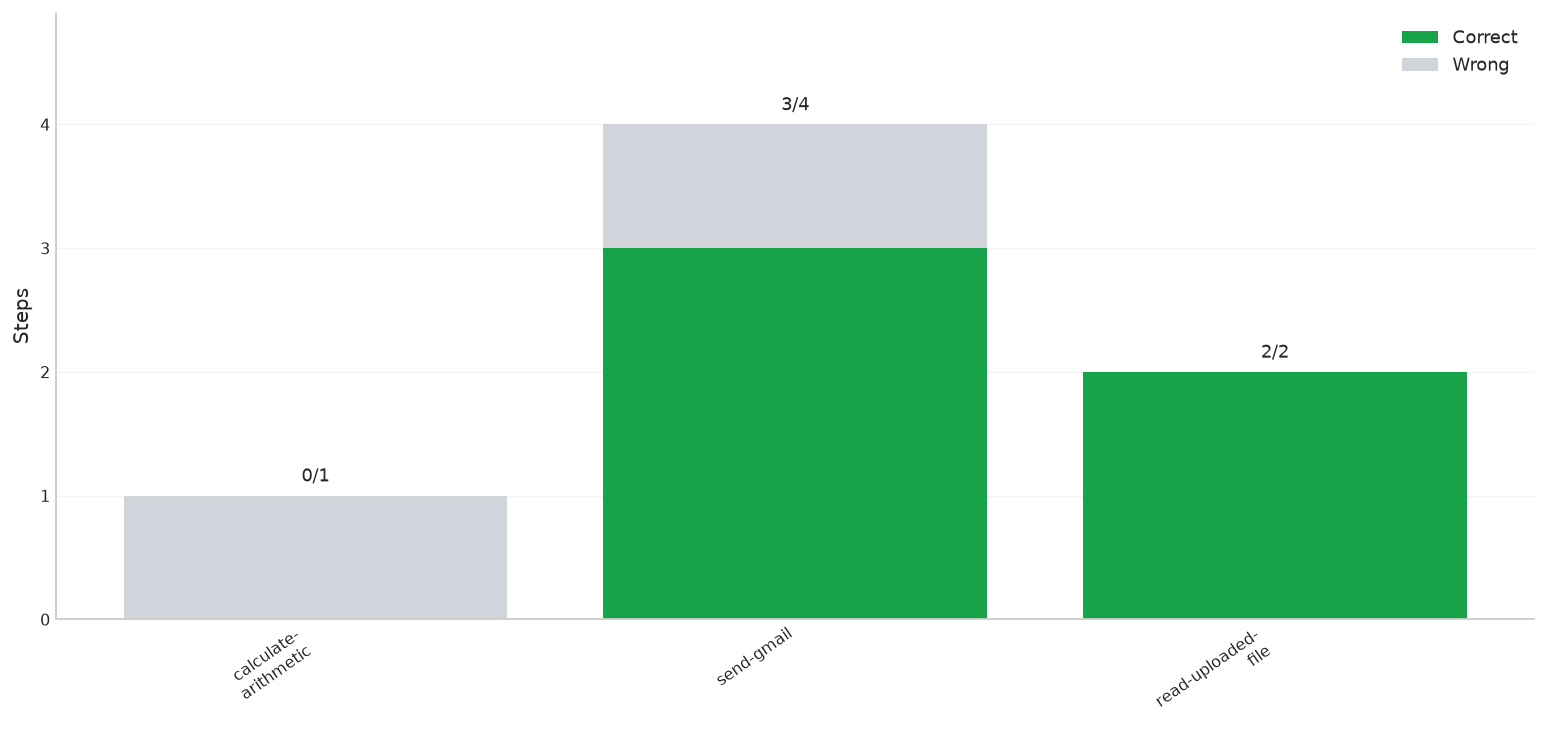

In [12]:
plot_df = metrics.sort_values(["step_rate", "total_steps"], ascending=[True, False])
labels = wrap_labels(plot_df["usecase"], width=16)

fig, ax = plt.subplots(figsize=(chart_width(len(plot_df)), 5.8))
correct_bars = ax.bar(labels, plot_df["correct_steps"], color="#16a34a", label="Correct")
ax.bar(
    labels,
    plot_df["wrong_steps"],
    bottom=plot_df["correct_steps"],
    color="#d1d5db",
    label="Wrong",
)

for index, (total, label) in enumerate(zip(plot_df["total_steps"], plot_df["step_label"])):
    ax.text(
        index,
        total + 0.08,
        label,
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_xlabel("")
ax.set_ylabel("Steps")
ax.set_ylim(0, max(plot_df["total_steps"].max() + 0.9, 1))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.tick_params(axis="x", rotation=35)
for tick in ax.get_xticklabels():
    tick.set_ha("right")
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)
ax.legend(loc="upper right", frameon=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()